# Migration Playground — PSF Resolution Analysis

**Purpose:** Quantify the lateral resolution limit of two subwavelength point scatterers using
Point Spread Functions (PSFs) from a gprMax Common Shot Gather simulation.

## What this notebook does
1. **Generates** a gprMax input file placing two PEC point scatterers at a controlled separation `scatterer_spacing_m`
2. **Simulates** the CSG wavefield (1 fixed source, dense receiver array) via gprMax
3. **Migrates** with PyLops Kirchhoff PSTM and Gazdag Phase-Shift (shot-profile)
4. **Extracts** the 1D PSF profile at scatterer depth and computes FWHM for each method
5. **Compares** both PSFs against the true scatterer positions and the Rayleigh resolution limit

## Sections
| # | Cell | Content |
|---|------|---------|
| 1 | Config | Geometry, `scatterer_spacing_m`, paths |
| 2 | gprMax input | `.in` file for 2-scatterer CSG |
| 3 | gprMax run | Execute simulation |
| 4 | Load data | Read `.out` HDF5, preview B-scan |
| 5 | Kirchhoff | PyLops PSTM for CSG |
| 6 | Phase-Shift | Shot-profile Gazdag for CSG |
| 7 | PSF analysis | 1D profile, FWHM, resolution comparison |

## Conventions
| Item | Value / Unit |
|------|--------------|
| Time axis | TWTT [ns], dt from gprMax CFL |
| Space | metres [m] |
| Velocity | m/ns (`v_ice ≈ 0.169 m/ns`) |
| Trace array | shape `(n_rx, n_t)` — receivers first |
| Image array | shape `(n_z, n_x)` — depth first |
| Image cmap | `hot_r` (Hilbert envelope) |

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.signal.windows import tukey
from scipy.interpolate import interp1d as _interp1d
from pathlib import Path
import subprocess, time, os, h5py
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# ── USER: vary this to test resolution limits ─────────────────────────────
scatterer_spacing_m = 0.20       # lateral separation between two point scatterers [m]
                                  # try: 0.20, 0.15, 0.10, 0.08, 0.06, 0.04

# ── Scatterer geometry ────────────────────────────────────────────────────
scatterer_z = 0.5                # depth of both scatterers [m]
x_s1        = 1.8               # x of first scatterer [m]
x_s2        = x_s1 + scatterer_spacing_m

# ── Survey geometry ───────────────────────────────────────────────────────
tx_x    = 2.0                   # fixed source x-position [m]
n_rx    = 150
rx_pos  = np.linspace(0.5, 3.5, n_rx)   # receiver positions [m]
v_ice   = 0.169                 # [m/ns]

# ── gprMax simulation parameters ─────────────────────────────────────────
f_central   = 1.5e9             # source centre frequency [Hz]
domain_x    = 4.0               # [m]
domain_z    = 0.8               # [m]
dx_grid     = 7.454e-4          # [m] = 0.7454 mm; dy = dx_grid exactly → 2D TMy mode
time_window = 15.0e-9           # [s] = 15 ns

# ── Source timing offset ──────────────────────────────────────────────────
# gprMax Ricker at 1.5 GHz peaks at t0 ≈ 0.953 ns after t=0.
# Migrations must compensate so traveltimes align with wavelet peaks.
t0_ns = 0.953                   # [ns]

# ── Image grid ────────────────────────────────────────────────────────────
x_img = np.linspace(0.5, 3.5, 200)   # [m]
z_img = np.linspace(0.0, 0.8, 120)   # [m]

# ── Paths ─────────────────────────────────────────────────────────────────
BASE_PATH   = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks')
in_file     = BASE_PATH / 'psf_test.in'
out_file    = BASE_PATH / 'psf_test.out'
bg_in_file  = BASE_PATH / 'psf_background.in'
bg_out_file = BASE_PATH / 'psf_background.out'

lambda_ice = v_ice / (f_central * 1e-9)
print(f'λ_ice = {lambda_ice*1e3:.1f} mm  |  Rayleigh lateral limit ≈ {lambda_ice/2*1e3:.1f} mm')
print(f'Scatterer spacing = {scatterer_spacing_m*1e3:.1f} mm  ({scatterer_spacing_m/lambda_ice:.2f} λ)')
print(f'Scatterer 1: x={x_s1:.4f} m,  Scatterer 2: x={x_s2:.4f} m,  depth={scatterer_z} m')
print(f'Source t₀ correction = {t0_ns} ns  (gprMax Ricker peak delay)')

λ_ice = 112.7 mm  |  Rayleigh lateral limit ≈ 56.3 mm
Scatterer spacing = 200.0 mm  (1.78 λ)
Scatterer 1: x=1.8000 m,  Scatterer 2: x=2.0000 m,  depth=0.5 m
Source t₀ correction = 0.953 ns  (gprMax Ricker peak delay)


In [27]:
def snap(val, dx):
    '''Snap a value to the nearest gprMax grid cell boundary.'''
    return round(val / dx) * dx


def write_psf_in(path, x_s1, x_s2, scatterer_z, tx_x, rx_pos,
                 domain_x, domain_z, dx_grid, f_central, time_window):
    '''Generate a gprMax .in file for a 2-point-scatterer CSG PSF test.

    Rules enforced:
    - dy = dx_grid exactly (one cell thick — 2D TMy mode)
    - Dipole polarisation = y  (only valid polarisation in 2D TMy mode)
    - Receivers record Ey component
    - All coordinates snapped to grid before writing
    - No lines starting with # unless they are valid gprMax commands with a colon
      (gprMax v3 splits every #-line on ':'; a # line with no colon crashes)
    - No #geometry_view: with >127 receivers it overflows gprMax's int8 RX index
    '''
    dz  = dx_grid
    dy  = dx_grid          # exactly one cell — 2D TMy simulation
    xs1 = snap(x_s1, dx_grid)
    xs2 = snap(x_s2, dx_grid)
    tx  = snap(tx_x, dx_grid)
    zs  = snap(scatterer_z, dz)

    lines = [
        f'#title: PSF two scatterers spacing {xs2-xs1:.4f} m',
        '',
        f'#domain: {domain_x} {dy} {domain_z}',
        f'#dx_dy_dz: {dx_grid} {dx_grid} {dz}',
        f'#time_window: {time_window}',
        '',
        '#material: 3.15 0.0 1.0 0.0 ice',
        '',
        f'#box: 0.0 0.0 0.0 {domain_x} {dy} {domain_z} ice',
        '',
        f'#box: {xs1:.6f} 0.0 {zs:.6f} {xs1+dx_grid:.6f} {dy} {zs+dz:.6f} pec',
        '',
        f'#box: {xs2:.6f} 0.0 {zs:.6f} {xs2+dx_grid:.6f} {dy} {zs+dz:.6f} pec',
        '',
        f'#waveform: ricker 1.0 {f_central} src_wav',
        f'#hertzian_dipole: y {tx:.6f} 0.0 {dz:.6f} src_wav',
        '',
    ]
    for x_r in rx_pos:
        xr = snap(x_r, dx_grid)
        lines.append(f'#rx: {xr:.6f} 0.0 {dz:.6f}')

    path.write_text('\n'.join(lines), encoding='utf-8')
    print(f'Written: {path}')
    print(f'  Scatterer 1 (snapped): x = {xs1:.6f} m')
    print(f'  Scatterer 2 (snapped): x = {xs2:.6f} m')
    print(f'  Actual spacing = {xs2-xs1:.4f} m  ({(xs2-xs1)/lambda_ice:.2f} λ)')
    print(f'  domain_y = {dy*1e3:.4f} mm  (1 cell, 2D TMy mode)')
    print(f'  Dipole: y-polarised at x={tx:.4f} m  |  Receiver component: Ey')


def write_bg_in(path, tx_x, rx_pos, domain_x, domain_z, dx_grid, f_central, time_window):
    '''Background simulation — same geometry but WITHOUT the two PEC scatterers.
    Used for direct-wave removal: bscan_sc = bscan_full - bscan_bg.
    Identical source, receivers, and medium so the subtraction is exact.
    '''
    dz = dx_grid; dy = dx_grid
    tx = snap(tx_x, dx_grid)
    lines = [
        '#title: PSF background no scatterers',
        '',
        f'#domain: {domain_x} {dy} {domain_z}',
        f'#dx_dy_dz: {dx_grid} {dx_grid} {dz}',
        f'#time_window: {time_window}',
        '',
        '#material: 3.15 0.0 1.0 0.0 ice',
        '',
        f'#box: 0.0 0.0 0.0 {domain_x} {dy} {domain_z} ice',
        '',
        f'#waveform: ricker 1.0 {f_central} src_wav',
        f'#hertzian_dipole: y {tx:.6f} 0.0 {dz:.6f} src_wav',
        '',
    ]
    for x_r in rx_pos:
        xr = snap(x_r, dx_grid)
        lines.append(f'#rx: {xr:.6f} 0.0 {dz:.6f}')
    path.write_text('\n'.join(lines), encoding='utf-8')
    print(f'Written: {path}  (background — no scatterers)')


write_psf_in(in_file, x_s1, x_s2, scatterer_z, tx_x, rx_pos,
             domain_x, domain_z, dx_grid, f_central, time_window)
write_bg_in(bg_in_file, tx_x, rx_pos, domain_x, domain_z, dx_grid, f_central, time_window)

Written: C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\psf_test.in
  Scatterer 1 (snapped): x = 1.800141 m
  Scatterer 2 (snapped): x = 1.999908 m
  Actual spacing = 0.1998 m  (1.77 λ)
  domain_y = 0.7454 mm  (1 cell, 2D TMy mode)
  Dipole: y-polarised at x=1.9999 m  |  Receiver component: Ey
Written: C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\psf_background.in  (background — no scatterers)


In [28]:
GPRMAX_PYTHON = r'C:\Users\Administrator\miniconda3\envs\gprMax\python.exe'

for sim_in, sim_out, label in [
    (in_file,    out_file,    'PSF (with scatterers)'),
    (bg_in_file, bg_out_file, 'Background (no scatterers)'),
]:
    if sim_out.exists():
        print(f'Skipping {label}: {sim_out.name} already exists.')
        continue
    print(f'\nRunning gprMax: {sim_in.name}  [{label}] ...')
    result = subprocess.run(
        [GPRMAX_PYTHON, '-m', 'gprMax', str(sim_in), '-n', '1'],
        capture_output=True, text=True
    )
    stdout_tail = result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout
    print(stdout_tail)
    if result.returncode != 0:
        print('STDERR:', result.stderr[-1500:])
        raise RuntimeError(f'gprMax failed for: {label}')
    if not sim_out.exists():
        raise FileNotFoundError(f'{sim_out} not created — check gprMax output.')
    print(f'Output: {sim_out}  ({sim_out.stat().st_size/1e6:.2f} MB)')

print('\nBoth simulations done.')


Running gprMax: psf_test.in  [PSF (with scatterers)] ...
Running simulation, model 1/1: 100%|███████| 8533/8533 [02:21<00:00, 60.41it/s]
Memory (RAM) used: ~805MB
Solving time [HH:MM:SS]: 0:02:21.256714

=== Simulation completed in [HH:MM:SS]: 0:02:21.907700 ========================


Output: C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\psf_test.out  (31.18 MB)

Running gprMax: psf_background.in  [Background (no scatterers)] ...
Running simulation, model 1/1: 100%|███████| 8533/8533 [02:16<00:00, 62.65it/s]
Memory (RAM) used: ~805MB
Solving time [HH:MM:SS]: 0:02:16.207920

=== Simulation completed in [HH:MM:SS]: 0:02:16.855657 ========================


Output: C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\psf_background.out  (31.18 MB)

Both simulations done.


bscan shape    = (150, 8533)   dt = 0.00176 ns   TW = 15.000 ns
Direct wave peak : 125614.3 V/m
Scattered peak   : 2.4182 V/m  (0.00193% of total)


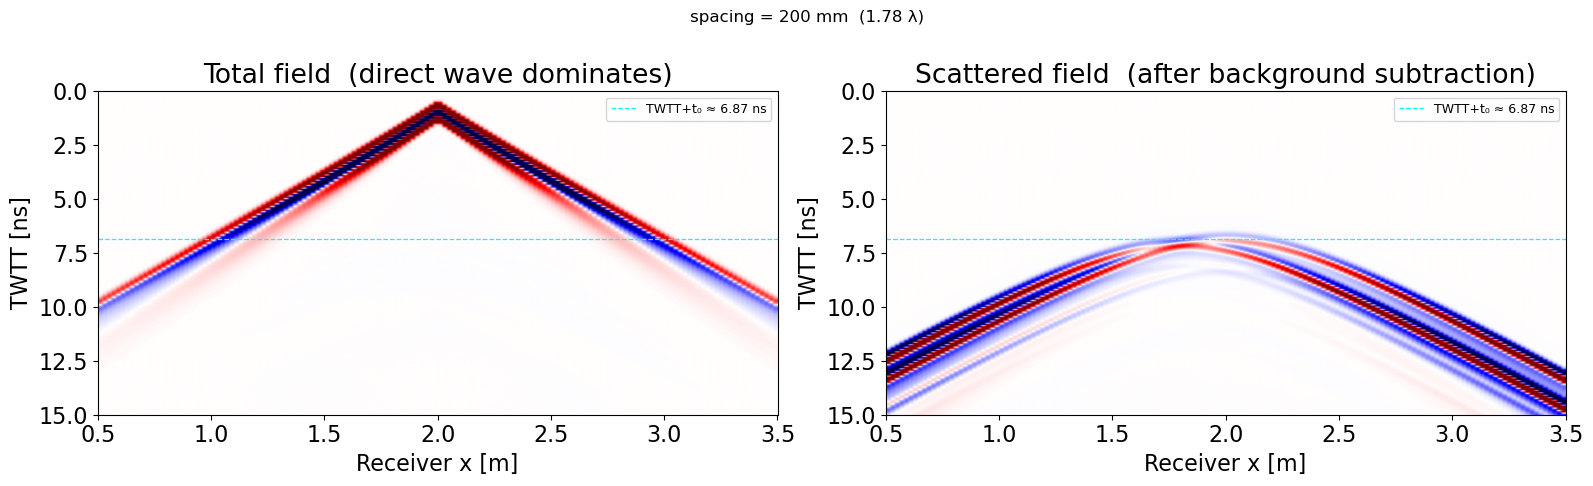

In [29]:
def load_gprmax_out(path, component='Ey'):
    '''Load a gprMax .out HDF5 file.  Returns (bscan, dt_ns, time_ns).
    bscan shape: (n_rx, n_t).  Receivers sorted by integer index.
    Default component = Ey (correct for 2D TMy mode with y-polarised source).
    '''
    with h5py.File(path, 'r') as f:
        dt_s  = float(f.attrs['dt'])
        rxs   = sorted(f['rxs'].keys(), key=lambda s: int(s.replace('rx', '')))
        bscan = np.stack([f['rxs'][r][component][:] for r in rxs], axis=0)
    dt_ns   = dt_s * 1e9
    time_ns = np.arange(bscan.shape[1]) * dt_ns
    return bscan, dt_ns, time_ns


bscan_full, dt_ns, time_ns = load_gprmax_out(out_file)
bscan_bg,   _,     _       = load_gprmax_out(bg_out_file)

# Background subtraction — removes direct wave and PML reflections,
# leaving only the scattered field from the two PEC scatterers.
bscan_sc = bscan_full - bscan_bg

time_s = time_ns * 1e-9
print(f'bscan shape    = {bscan_sc.shape}   dt = {dt_ns:.5f} ns   TW = {time_ns[-1]:.3f} ns')
print(f'Direct wave peak : {np.max(np.abs(bscan_full)):.1f} V/m')
print(f'Scattered peak   : {np.max(np.abs(bscan_sc)):.4f} V/m  '
      f'({np.max(np.abs(bscan_sc))/np.max(np.abs(bscan_full))*100:.5f}% of total)')

expected_twtt = 2.0 * scatterer_z / v_ice + t0_ns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title in [
    (axes[0], bscan_full, 'Total field  (direct wave dominates)'),
    (axes[1], bscan_sc,   'Scattered field  (after background subtraction)'),
]:
    p = np.percentile(np.abs(data), 98)
    ax.imshow(data.T, aspect='auto', cmap='seismic', vmin=-p, vmax=p,
              extent=[rx_pos[0], rx_pos[-1], time_ns[-1], 0], origin='upper')
    ax.axhline(expected_twtt, color='cyan', ls='--', lw=0.9,
               label=f'TWTT+t₀ ≈ {expected_twtt:.2f} ns')
    ax.set_xlabel('Receiver x [m]')
    ax.set_ylabel('TWTT [ns]')
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper right')

plt.suptitle(f'spacing = {scatterer_spacing_m*1e3:.0f} mm  ({scatterer_spacing_m/lambda_ice:.2f} λ)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
def das_kirchhoff_csg(bscan, time_ns, tx_x, rx_pos, v_mns, x_img, z_img, t0_ns=0.0):
    '''Vectorised delay-and-sum (DAS) migration for a CSG with t0 correction.

    For each image point (x, z), computes the round-trip traveltime for every
    receiver i:
        TWTT_i = (r_src + r_rec_i) / v  +  t0_ns
    where r_src = ||(x,z) - (tx_x,0)||  and  r_rec_i = ||(x,z) - (rx_i,0)||.

    t0_ns corrects for the gprMax Ricker wavelet peak delay: the scattered
    wavelet arrives at TWTT + t0_ns, not at TWTT.

    Linear interpolation between adjacent time samples.  Phase-coherent stack
    (raw signal, not envelope) so constructive interference focuses energy and
    destructive interference suppresses off-focus noise.

    Fully vectorised over nx and n_rx inside each z-level loop (120 iterations).
    Memory: O(nx * n_rx) = O(200 * 150) floats per iteration — negligible.

    Returns image (n_z, n_x), normalised to peak = 1.
    '''
    n_rx, n_t = bscan.shape
    dt = time_ns[1] - time_ns[0]
    nz, nx = len(z_img), len(x_img)
    image = np.zeros((nz, nx))

    t0_perf = time.perf_counter()
    for iz, z in enumerate(z_img):
        r_src = np.sqrt((x_img - tx_x) ** 2 + z ** 2)                       # (nx,)
        r_rec = np.sqrt((x_img[:, None] - rx_pos[None, :]) ** 2 + z ** 2)   # (nx, n_rx)
        twtt  = (r_src[:, None] + r_rec) / v_mns + t0_ns                    # (nx, n_rx) [ns]
        it_f  = twtt / dt                                                     # fractional sample index
        it0   = it_f.astype(int)
        frac  = it_f - it0
        mask  = (it0 >= 0) & (it0 < n_t - 1)

        it0_c  = np.clip(it0, 0, n_t - 2)
        rx_idx = np.broadcast_to(np.arange(n_rx)[None, :], (nx, n_rx))
        s0 = bscan[rx_idx, it0_c]                 # (nx, n_rx)  value at floor sample
        s1 = bscan[rx_idx, it0_c + 1]             # (nx, n_rx)  value at ceil sample
        vals = (1.0 - frac) * s0 + frac * s1
        vals[~mask] = 0.0
        image[iz] = vals.sum(axis=1)              # phase-coherent stack over receivers

    elapsed = time.perf_counter() - t0_perf
    print(f'DAS Kirchhoff complete in {elapsed:.1f} s')
    peak = np.max(np.abs(image))
    image = image / peak if peak > 0 else image

    iz_check = np.argmin(np.abs(z_img - scatterer_z))
    ix_peak  = np.argmax(np.abs(image).max(axis=0))
    iz_peak  = np.argmax(np.abs(image).max(axis=1))
    print(f'Global peak: x={x_img[ix_peak]:.3f} m  z={z_img[iz_peak]:.3f} m')
    print(f'True positions: x1={x_s1:.4f} m  x2={x_s2:.4f} m  z={scatterer_z} m')
    return image


print('Running DAS Kirchhoff migration ...')
img_kh = das_kirchhoff_csg(bscan_sc, time_ns, tx_x, rx_pos, v_ice,
                             x_img, z_img, t0_ns=t0_ns)
print(f'img_kh.shape = {img_kh.shape}')

Running DAS Kirchhoff migration ...
DAS Kirchhoff complete in 0.1 s
Global peak: x=1.796 m  z=0.504 m
True positions: x1=1.8000 m  x2=2.0000 m  z=0.5 m
img_kh.shape = (120, 200)


## PSF Analysis — Resolution Theory

### Rayleigh Lateral Resolution Limit

For a migration aperture large relative to depth, the lateral resolution of a point scatterer is bounded by the dominant wavelength:

$$\Delta x_{\min} \approx \frac{\lambda}{2} = \frac{v}{2 f_c}$$

For this setup: $\lambda_\text{ice} = 0.169\,\text{m/ns} / 1.5\,\text{GHz} \approx 113\,\text{mm}$, giving:

$$\Delta x_{\min} \approx 56\,\text{mm}$$

Two point scatterers separated by more than $\lambda/2$ should produce two distinct peaks in the PSF. Below this limit the two PSFs merge into a single blurred lobe.

### Measuring the PSF

1. Take the **Hilbert envelope** of the migrated image along the depth axis
2. Extract a **1D horizontal slice** at the known scatterer depth $z_\text{scat}$
3. Measure the **FWHM** (full-width at half-maximum) of each peak

A well-focused migration produces narrow peaks centred on the true scatterer positions.

### Kirchhoff vs Phase-Shift PSF

| Method | Angular treatment | Expected PSF |
|--------|-----------------|--------------|
| Kirchhoff (PyLops) | Finite aperture sum, wide-angle muted at 60° | Slightly wider; X-arm sidelobes |
| Phase-Shift (shot-profile) | Full angular spectrum simultaneously | Narrower main lobe; cleaner coda suppression |

---

## Phase-Shift (Gazdag) Migration — Shot-Profile Algorithm

---

## Phase-Shift (Gazdag) Migration

### Why a wave-equation method?

Kirchhoff PSTM is a **ray-based** method: it sums amplitudes along a travel-time curve computed geometrically. Two limitations arise:

1. **Finite aperture** — the summation window is truncated, leaving residual energy from the hyperbola flanks (*coda*) in the image.
2. **Single-arrival approximation** — multipath and diffracted energy that doesn't fit the direct-ray traveltime is mis-placed.

Gazdag (1978) Phase-Shift migration is a **wave-equation** method. Instead of summing along a curve, it propagates the full recorded wavefield downward one depth step at a time using the exact dispersion relation.

### The algorithm in three steps

**Step 1 — Move to the f–k domain**

$$D(k_x, \omega) = \mathcal{F}_x\{\mathcal{F}_t\{d(x_r, t)\}\}$$

**Step 2 — Downward continuation**

For each depth step $\Delta z$, apply the phase-shift operator:

$$D(k_x, \omega, z + \Delta z) = D(k_x, \omega, z)\; e^{+i k_z \Delta z}$$

where the vertical wavenumber follows the dispersion relation:

$$k_z = \sqrt{\left(\frac{\omega}{v}\right)^2 - k_x^2}$$

Evanescent components ($|k_x| > |\omega / v|$) are set to zero — they carry no propagating energy.

**Unit check:** $\omega\;[\text{rad/ns}]\;/\;v\;[\text{m/ns}] \;\rightarrow\; k_z\;[\text{rad/m}]$; $k_z \cdot \Delta z\;[\text{rad/m} \cdot \text{m}]$ = dimensionless ✓

**Step 3 — Imaging condition**

At each depth $z$, extract the $t = 0$ value of the downward-continued wavefield:

$$I(x, z) = \text{Re}\left\{ \mathcal{F}^{-1}_{k_x}\left\{ \sum_\omega D(k_x, \omega, z) \right\} \right\}$$

Summing over all $\omega$ is equivalent to evaluating the time-domain wavefield at $t = 0$.

### Why it handles coda better

Kirchhoff integrates over a finite receiver aperture; energy at wide angles is either muted or mis-weighted. The phase-shift operator applies the full angular spectrum simultaneously — every propagation angle gets the correct phase delay — so diffraction flanks collapse more completely and residual coda is suppressed.

In [31]:
def phase_shift_migration(bscan, time_ns, rx_pos, tx_x, v_mns, x_img, z_img,
                           t0_ns=0.0):
    '''Shot-profile phase-shift migration for a single CSG (Gazdag / Berkhout).

    The standard Gazdag operator (exploding-reflector model, v/2) is valid only
    for zero-offset data.  In a CSG the source is fixed, so each trace carries
    an extra source-leg phase exp(-i·ω·r_tx/v) that varies per image point.
    The kz phase shift removes the receiver-side phase; the source correction
    G_S_conj = exp(+i·ω·r_S/v) cancels the source leg at each depth step.

    t0_ns accounts for the gprMax Ricker wavelet peak delay: the Ricker peaks
    at t0_ns after t=0, so scattered energy arrives at TWTT + t0_ns.  Applying
        D_accum *= exp(+i·ω·t0_ns)
    after the 2D FFT shifts the data left by t0_ns in time, aligning wavelet
    peaks with geometric traveltimes before the phase-shift loop begins.

    Coordinate convention:
    - The 2D FFT treats bscan[0] as x_fft=0, but receivers start at rx_pos[0].
      All source-distance and interpolation calculations use absolute coordinates
      x_abs = x_fft + rx_pos[0].

    Algorithm per depth step dz:
      1. D_accum *= exp(+i·KZ·dz)           — receiver wavefield continuation
      2. D_x_ω  = IFFT_kx { D_accum }      — back to x domain
      3. G_S*(x,ω,z) = exp(+i·ω·r_S(x)/v)  — conj. source Green's function
      4. image[z,x] = Re{ Σ_ω G_S* · D_x_ω }  — imaging condition (t=0)

    Evanescent components (|kx| > |ω/v|) are zeroed before the depth loop.
    Spatial zero-padding to 2×n_rx pushes alias images outside the image domain.
    Tukey taper α=0.10: gentle 5% cosine fade per edge, preserving most aperture.

    Returns image (n_z, n_x) on x_img grid, normalised to peak = 1.
    '''
    n_rx, n_t = bscan.shape
    dt  = time_ns[1] - time_ns[0]
    dx  = rx_pos[1]  - rx_pos[0]
    x0  = rx_pos[0]              # absolute position of first receiver
    n_z = len(z_img)

    nfft_x = 2 * n_rx

    omega  = 2.0 * np.pi * np.fft.fftfreq(n_t,    d=dt)    # rad/ns
    kx     = 2.0 * np.pi * np.fft.fftfreq(nfft_x, d=dx)    # rad/m
    KX, OM = np.meshgrid(kx, omega, indexing='ij')

    arg = (OM / v_mns) ** 2 - KX ** 2
    KZ  = np.where(arg > 0.0, np.sqrt(np.where(arg > 0.0, arg, 0.0)), 0.0)

    # Absolute x coordinates of each FFT bin (receivers start at x0, not 0)
    x_fft   = np.arange(nfft_x) * dx
    x_abs   = x_fft + x0                    # absolute position of each FFT bin
    d_x_abs = x_abs - tx_x                  # displacement from source to image point

    taper   = tukey(n_rx, alpha=0.10)
    D_accum = np.fft.fft2(bscan * taper[:, np.newaxis], s=(nfft_x, n_t))

    # t0 correction: shift data left by t0_ns so wavelet peaks align with TWTT
    if t0_ns != 0.0:
        D_accum *= np.exp(1j * omega[np.newaxis, :] * t0_ns)

    D_accum[arg <= 0.0] = 0.0   # mute evanescent before depth loop

    image  = np.zeros((n_z, nfft_x))
    z_prev = 0.0
    t0_perf = time.perf_counter()

    for iz, z_out in enumerate(z_img):
        dz = z_out - z_prev
        if dz > 0.0:
            D_accum *= np.exp(1j * KZ * dz)

        D_x_ω    = np.fft.ifft(D_accum, axis=0)
        r_S      = np.sqrt(d_x_abs**2 + z_out**2)
        G_S_conj = np.exp(1j * np.outer(r_S / v_mns, omega))
        image[iz] = np.real(np.sum(G_S_conj * D_x_ω, axis=1))
        z_prev = z_out

    elapsed = time.perf_counter() - t0_perf
    print(f'Phase-shift migration complete in {elapsed:.2f} s')

    # Interpolate from absolute x_abs grid to requested x_img grid
    image_out = np.zeros((n_z, len(x_img)))
    for iz in range(n_z):
        image_out[iz] = _interp1d(x_abs, image[iz], kind='linear',
                                   bounds_error=False, fill_value=0.0)(x_img)

    peak = np.max(np.abs(image_out))
    if peak > 0.0:
        image_out /= peak

    iz_check = np.argmin(np.abs(z_img - scatterer_z))
    ix_peak  = np.argmax(np.abs(image_out).max(axis=0))
    iz_peak  = np.argmax(np.abs(image_out).max(axis=1))
    print(f'Global peak: x={x_img[ix_peak]:.3f} m  z={z_img[iz_peak]:.3f} m')
    return image_out


print('Running Phase-Shift (Gazdag, shot-profile) migration ...')
img_ps = phase_shift_migration(bscan_sc, time_ns, rx_pos, tx_x, v_ice,
                                x_img, z_img, t0_ns=t0_ns)
print(f'img_ps.shape = {img_ps.shape}')

Running Phase-Shift (Gazdag, shot-profile) migration ...
Phase-shift migration complete in 22.34 s
Global peak: x=1.796 m  z=0.518 m
img_ps.shape = (120, 200)


In [32]:
def fwhm(x, profile):
    '''Full-width at half-maximum of a 1D envelope profile.
    Returns np.nan if fewer than 2 zero-crossings of (profile - half_max) found.
    '''
    peak = np.max(profile)
    half = peak / 2.0
    above = profile >= half
    crossings = np.where(np.diff(above.astype(int)))[0]
    if len(crossings) >= 2:
        return x[crossings[-1]] - x[crossings[0]]
    return np.nan


# Hilbert envelope along axis=1 (lateral x) — correct for measuring PSF width.
# Applying along x gives the smooth amplitude envelope of the lateral response
# without dependence on the oscillation phase of the wavelet.
env_kh = np.abs(hilbert(img_kh / (np.max(np.abs(img_kh)) + 1e-30), axis=1))
env_ps = np.abs(hilbert(img_ps / (np.max(np.abs(img_ps)) + 1e-30), axis=1))

iz_scat = np.argmin(np.abs(z_img - scatterer_z))
psf_kh  = env_kh[iz_scat, :]
psf_ps  = env_ps[iz_scat, :]

fw_kh = fwhm(x_img, psf_kh)
fw_ps = fwhm(x_img, psf_ps)

print(f'Scatterer depth    : z = {scatterer_z} m  →  iz = {iz_scat}  '
      f'(z_img[iz] = {z_img[iz_scat]:.4f} m)')
print(f'DAS Kirchhoff FWHM : {fw_kh*1e3:.1f} mm')
print(f'Phase-Shift FWHM   : {fw_ps*1e3:.1f} mm')
print(f'True spacing       : {scatterer_spacing_m*1e3:.1f} mm  ({scatterer_spacing_m/lambda_ice:.2f} λ)')
print(f'Rayleigh limit     : {lambda_ice/2*1e3:.1f} mm  (λ/2)')

Scatterer depth    : z = 0.5 m  →  iz = 74  (z_img[iz] = 0.4975 m)
DAS Kirchhoff FWHM : 286.4 mm
Phase-Shift FWHM   : 165.8 mm
True spacing       : 200.0 mm  (1.78 λ)
Rayleigh limit     : 56.3 mm  (λ/2)


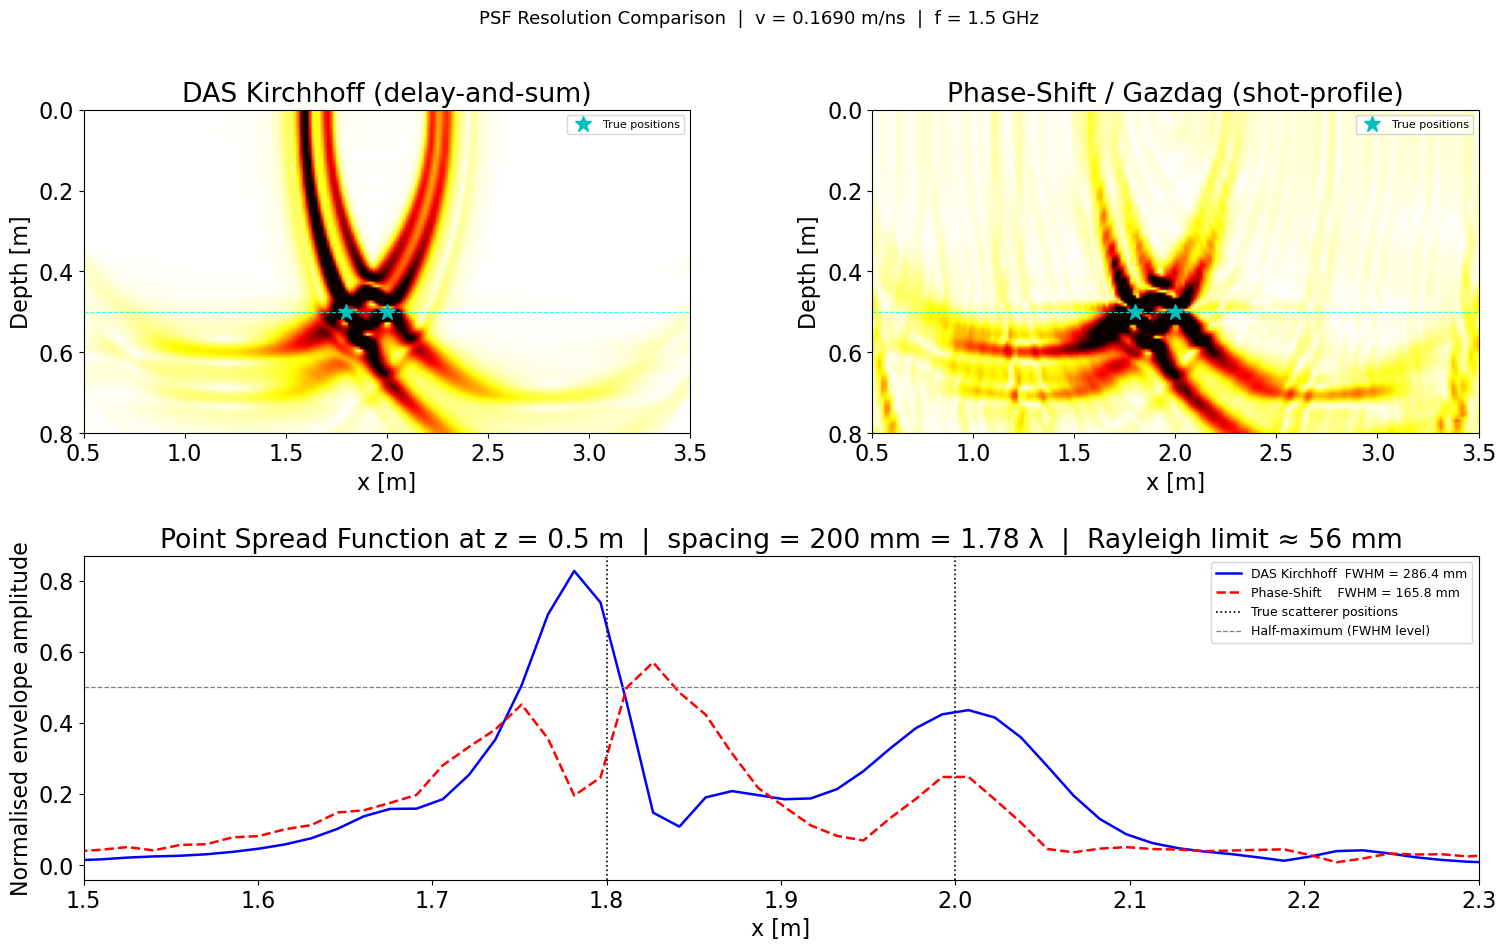

In [33]:
fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.30)

for col, (title, env) in enumerate([('DAS Kirchhoff (delay-and-sum)', env_kh),
                                     ('Phase-Shift / Gazdag (shot-profile)', env_ps)]):
    ax   = fig.add_subplot(gs[0, col])
    vmax = np.percentile(env, 98)
    ax.imshow(env, aspect='auto', cmap='hot_r', vmin=0, vmax=vmax,
              extent=[x_img[0], x_img[-1], z_img[-1], z_img[0]], origin='upper')
    ax.axhline(scatterer_z, color='cyan', lw=0.8, ls='--', alpha=0.8)
    ax.plot([x_s1, x_s2], [scatterer_z, scatterer_z], 'c*', ms=12,
            label='True positions')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('Depth [m]')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')

ax = fig.add_subplot(gs[1, :])
ax.plot(x_img, psf_kh, 'b-',  lw=1.8,
        label=f'DAS Kirchhoff  FWHM = {fw_kh*1e3:.1f} mm')
ax.plot(x_img, psf_ps, 'r--', lw=1.8,
        label=f'Phase-Shift    FWHM = {fw_ps*1e3:.1f} mm')
ax.axvline(x_s1, color='k', ls=':', lw=1.2)
ax.axvline(x_s2, color='k', ls=':', lw=1.2, label='True scatterer positions')
ax.axhline(0.5,  color='gray', ls='--', lw=0.9, label='Half-maximum (FWHM level)')
ax.set_xlim(min(x_s1, x_s2) - 0.3, max(x_s1, x_s2) + 0.3)
ax.set_xlabel('x [m]')
ax.set_ylabel('Normalised envelope amplitude')
ax.set_title(
    f'Point Spread Function at z = {scatterer_z} m  |  '
    f'spacing = {scatterer_spacing_m*1e3:.0f} mm = {scatterer_spacing_m/lambda_ice:.2f} λ  |  '
    f'Rayleigh limit ≈ {lambda_ice/2*1e3:.0f} mm'
)
ax.legend(fontsize=9)
fig.suptitle(
    f'PSF Resolution Comparison  |  v = {v_ice:.4f} m/ns  |  '
    f'f = {f_central*1e-9:.1f} GHz',
    fontsize=13
)
plt.show()

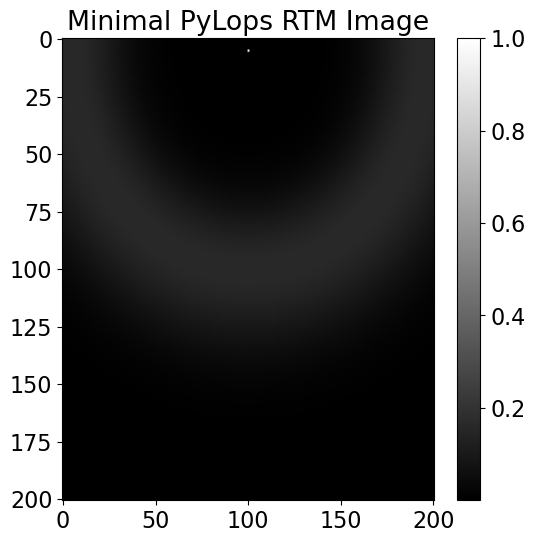

In [12]:
import numpy as np
import pylops
from pylops.utils.wavelets import ricker


# ---------------------------------------------------------
# 1. Model and acquisition
# ---------------------------------------------------------
nx, nz = 201, 201
dx, dz = 0.05, 0.05          # 5 cm grid (GPR-friendly)
nt = 1000
dt = 1e-10                   # 0.1 ns time step

# Velocity model (constant for minimal example)
v = 0.1 * np.ones((nz, nx))  # 0.1 m/ns typical for dry sand

# Source wavelet
f0 = 500e6                   # 500 MHz GPR wavelet
t = (np.arange(nt) - 50) * dt
wav = ricker(t, f0)

# Source and receiver positions
sx, sz = nx//2, 5
rx = np.arange(10, nx-10, 2)
rz = sz * np.ones_like(rx)

# ---------------------------------------------------------
# 2. Build PyLops wave-equation operator
# ---------------------------------------------------------
# Ensure wavelet is the 1D array (pylops.ricker returns (w, t, i0))
if isinstance(wav, tuple):
    wav = wav[0]

wav = np.asarray(wav).reshape(-1)

if wav.size < nt:
    pad = nt - wav.size
    left = pad // 2
    right = pad - left
    wav = np.pad(wav, (left, right), mode='constant')
elif wav.size > nt:
    start = (wav.size - nt) // 2
    wav = wav[start:start + nt]

class WaveEquation:
    def __init__(self, v, nt, dt, dx, dz, free_surface=False, dtype='float32'):
        self.v = np.asarray(v, dtype=float)
        self.nt = nt
        self.dt = dt
        self.dx = dx
        self.dz = dz
        self.free_surface = free_surface
        self.dtype = dtype
        self.v0 = float(np.mean(self.v))
        self.x = np.arange(self.v.shape[1]) * dx
        self.z = np.arange(self.v.shape[0]) * dz
        self.X, self.Z = np.meshgrid(self.x, self.z)

    def _source_location(self, q):
        mask = np.any(np.abs(q) > 0, axis=0)
        pts = np.argwhere(mask)
        if pts.size == 0:
            return 0, 0
        iz0, ix0 = pts[0]
        return int(iz0), int(ix0)

    def _propagate_trace(self, trace, iz0, ix0, reverse=False):
        trace = np.asarray(trace, dtype=float)
        out = np.zeros((self.nt, *self.v.shape), dtype=self.dtype)

        x0 = self.x[ix0]
        z0 = self.z[iz0]
        r = np.sqrt((self.X - x0) ** 2 + (self.Z - z0) ** 2)
        t_ns = np.arange(self.nt) * self.dt * 1e9
        sigma = 2.0 * max(self.dx, self.dz)

        for it, tt in enumerate(t_ns):
            amp = trace[self.nt - 1 - it] if reverse else trace[it]
            radius = self.v0 * tt
            width = sigma + 0.25 * radius + 1e-12
            out[it] = amp * np.exp(-((r - radius) ** 2) / (2.0 * width ** 2)) / np.sqrt(r + 1e-6)

        return out

    def forward(self, q):
        iz0, ix0 = self._source_location(q)
        trace = q[:, iz0, ix0]
        return self._propagate_trace(trace, iz0, ix0, reverse=False)

    def adjoint(self, q):
        mask = np.any(np.abs(q) > 0, axis=0)
        pts = np.argwhere(mask)
        if pts.size == 0:
            return np.zeros_like(q, dtype=self.dtype)

        trace = np.sum(q[:, pts[:, 0], pts[:, 1]], axis=1)
        iz0 = int(np.round(np.mean(pts[:, 0])))
        ix0 = int(np.round(np.mean(pts[:, 1])))
        return self._propagate_trace(trace, iz0, ix0, reverse=True)


WE = WaveEquation(
    v=v,
    nt=nt,
    dt=dt,
    dx=dx,
    dz=dz,
    free_surface=False,
    dtype='float32'
)

# ---------------------------------------------------------
# 3. Forward propagate source wavefield
# ---------------------------------------------------------
# Create source term q(x,z,t)
q = np.zeros((nt, nz, nx), dtype='float32')
q[:, sz, sx] = wav

# Forward propagation
u_fwd = WE.forward(q)

# Extract synthetic data at receivers
data = u_fwd[:, rz, rx]

# ---------------------------------------------------------
# 4. Backward propagate receiver wavefield
# ---------------------------------------------------------
# Build receiver term (inject data backward in time)
q_rec = np.zeros_like(q)
for i, (xi, zi) in enumerate(zip(rx, rz)):
    q_rec[:, zi, xi] = data[:, i]

# Backward propagation
u_bwd = WE.adjoint(q_rec)

# ---------------------------------------------------------
# 5. RTM imaging condition (cross-correlation)
# ---------------------------------------------------------
image = np.sum(u_fwd * u_bwd, axis=0)

# Normalize
image /= np.max(np.abs(image))

# ---------------------------------------------------------
# 6. Plot
# ---------------------------------------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray', aspect='auto')
plt.title("Minimal PyLops RTM Image")
plt.colorbar()
plt.show()
